<a href="https://colab.research.google.com/github/Rpvermaak/sifra-potato-yield-analysis/blob/main/notebooks/Sifra_yield_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Sifra Paradox – Multi-Site Yield Analysis
---
**Client:** Commercial Potato Producer | Location: Soutpansberg, Limpopo, SA


**Author:** Ruben Vermaak


**Date:** January 2026


---
## Executive Summary


This project investigates the volatile yield performance of **Sifra potatoes** across two geographically distinct sites: the southern "Mist Belt" and the northern "Rain Shadow" of the Southpanberg mountains. By reconstructing environmental conditions from Season 1 (Failure) and Season 2 (Success), the analysis identifies the critical climate thresholds required for Sifra optimization.


## Problem Statement


A local producer experiences significant yield loss with the Sifra variety in Season 1, followed by an outperformance in Season 2 despite a reduction in planted area.


**Question**: Was the Season 2 success a result of favourable climate timing, or site-specific management?


**Goal**: Define a data-driven "Planting Window" to minimize risk and maximize tuber bulking for future seasons.

## Methodology and Technology


Since primary farm records are unavailable, this project utilizes Remote Sensing and Reanalysis Data to simulate the production environment.


**Data ingestion**: `NASA POWER API` (Meteorology), `Sentinel-2` via `Google Earth Engine` (Vegetation indices).


**Analysis**: `Pandas` (Time-series alignment), `Scikit-Learn`(Correlation analysis and Feature importance).


**Geospatial**: `GeoPandas` and `Shapely` (Field boundary mapping).


**Visualization**: `Plotly` (Interactive environmental dashboard) and  `Falium` (Satellite map overlays).

## Data Sources

| Source | Type | Parameters |
|---|---|---|
|NASA POWER | Weather | Daily Min/Max Temp, Precipitation, Solar Radiation.|
| ESA Sentinel-2 | Imagery | NDVI (Greenness Proxy) & NDMI (Moisture Stress).|
| SoilGrids.org | Soil | pH, Nitrogen, and Clay content for the Limpopo region. |
|ARC South Africa|Domain|Sifra variety phenology and growth stages.|


## Research Hypotheses


* **The Mist Belt Effect(South)**: High humidity during the "Late Blight" window in Season1 caused the initial yield collapse.


* **The Thermal Threshold (North)**: Sifra's long growing cycle benefited from the specific night-time temperature cooling observation in Season 2.


* **NDVI Correlation**: Satellite-derived greenness peaks will correlate with the $R^2$ of the historical harvest success.


### NDVI (Normalized Difference Vegetation Index)
It measures the health of the plant by comparing how much Near-Infrared (NIR) light is reflected versus how much Visible Red light is absorbed.

$$NDVI = \frac{NIR - Red}{NIR + Red}$$

Healthy potato leaves absorb Red light for photosynthesis and reflect NIR. A high NDVI value (close to 1.0) indicates a dense, healthy canopy. A sudden drop in NDVI during the growing season can pinpoint exactly when the "Season 1" failure started—likely due to blight or water stress.


### GDD (Growing Degree Days)


$$GDD = \max\left(\frac{T_{max} + T_{min}}{2} - T_{base}, 0\right)$$

* The Potato Constant: For potatoes, the base temperature ($T_{base}$) is typically 7°C. Growth generally stops if the temperature exceeds 30°C.

* Why it matters for the Sifra project: The Sifra variety has a specific GDD requirement to reach maturity. By calculating this for both the North and South farms, you can see if the North farm "caught up" or if the South farm "stalled" due to the cooler, misty conditions of the Soutpansberg.

## Project Status

* [ ] Phase 1: Environmental Reconstruction (NASA/Sentinel Data Pull)

* [ ] Phase 2: Exploratory Data Analysis (Correlation of Weather vs. NDVI)

* [ ] Phase 3: Feature Engineering (Growing Degree Days & Stress Indices)

* [ ] Phase 4: Insight Synthesis & Farmer Proposal Generation

## Phase 1: Environmental Reconstruction (NASA/Sentinel Data Pull)



## Install Libraries for Geospatial Data and API Requests

The fist step will be to install geopandas, rasterio, folium, requests, xarray, netCDF4, and earthengine-api to enable geospatial data handling, API requests for weather data, and Google Earth Engine access, then authenticate Google Earth Engine.


In [1]:
print("Installing essential Python libraries...")
!pip install geopandas rasterio folium requests xarray netCDF4
print("Libraries installed successfully.")

Installing essential Python libraries...
Libraries installed successfully.


In [2]:
print("Installing earthengine-api and whiteboxgui...")
!pip install earthengine-api whiteboxgui
print("earthengine-api and whiteboxgui installed successfully.")

Installing earthengine-api and whiteboxgui...
earthengine-api and whiteboxgui installed successfully.


In [3]:
import ee

# Authenticate the Earth Engine account.
ee.Authenticate()

# Initialize the Earth Engine API with your Google Cloud Project ID.
# IMPORTANT: Replace 'your-earthengine-project-id' with your actual Google Cloud Project ID.
# You can find or create a project ID at console.cloud.google.com
ee.Initialize(project='sifra-potato-yield-analysis')

### Retrieving Meteorological Data from NASA POWER API

Now that the environment is set up, the next crucial step in 'Phase 1: Environmental Reconstruction' is to gather daily meteorological data from the NASA Prediction Of Worldwide Energy Resources (POWER) API. This API provides global datasets tailored for various applications, including agricultural modeling.

This analysis will target the coordinates for both the 'South' (Mist Belt) and 'North' (Arid) farm sites. Historical data for each location will be requested covering Season 1 and Season 2. The key parameters that will be extracted include:

*   **Temperature:** Daily Minimum (T2M_MIN) and Maximum (T2M_MAX) Air Temperature at 2 Meters.
*   **Precipitation:** Daily Precipitation (PRECTOTCORR).
*   **Solar Radiation:** Daily Surface Incident Shortwave Flux (ALLSKY_SFC_SW_DWN).

This data will form the baseline for understanding the climate conditions during both seasons and will be instrumental in calculating metrics like Growing Degree Days (GDD) and identifying potential thermal stress periods for the Sifra potato variety.

In [4]:
import requests
import pandas as pd
import io

def fetch_nasa_weather(lat, lon, start_date, end_date, site_name):
    """
    Fetches daily agroclimatology data from NASA POWER API.
    Dates format: YYYYMMDD
    """
    base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    # Parameters relevant to Sifra Potatoes:
    # T2M_MAX/MIN: Temperature thresholds for tuber bulking
    # PRECTOTCORR: Corrected precipitation (Rainfall)
    # RH2M: Humidity (Blight risk indicator)
    # ALLSKY_SFC_SW_DWN: Solar radiation (Photosynthesis energy)
    params = {
        "parameters": "T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN",
        "community": "AG", # Agroclimatology community
        "longitude": lon,
        "latitude": lat,
        "start": start_date,
        "end": end_date,
        "format": "JSON"
    }

    print(f"📡 Fetching data for {site_name}...")
    response = requests.get(base_url, params=params)

    if response.status_code == 200:
        data = response.json()
        # Extract the parameter data
        features = data['properties']['parameter']
        df = pd.DataFrame(features)
        df.index.name = 'Date'
        df = df.reset_index()
        df['Site'] = site_name
        # Convert index strings to actual datetime objects
        df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')
        return df
    else:
        print(f"❌ Error fetching {site_name}: {response.status_code}")
        return None

# --- CONFIGURATION ---
# Southern Farm (Kalkoven huis / Mist Belt)
south_coords = {"lat": -23.1148, "lon": 29.5100}

# Northern Farm (Vetfontein / Arid Rain Shadow)
north_coords = {"lat": -22.8111, "lon": 29.4217}

# Season 1 Failure vs Season 2 Success window (e.g., Oct 2023 to May 2025)
start = "20231001"
end = "20250531"

# --- EXECUTION ---
df_south = fetch_nasa_weather(south_coords["lat"], south_coords["lon"], start, end, "South_MistBelt")
df_north = fetch_nasa_weather(north_coords["lat"], north_coords["lon"], start, end, "North_Arid")

# Combine into one master DataFrame for analysis
if df_south is not None and df_north is not None:
    full_data = pd.concat([df_south, df_north], ignore_index=True)
    print("✅ Success! Data combined.")
    display(full_data.head())

📡 Fetching data for South_MistBelt...
📡 Fetching data for North_Arid...
✅ Success! Data combined.


,Date,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN,Site
0,2023-10-01,32.81,14.59,0.03,37.95,25.26,South_MistBelt
1,2023-10-02,24.58,11.90,0.03,58.95,21.08,South_MistBelt
2,2023-10-03,31.14,10.48,0.04,47.78,26.92,South_MistBelt
3,2023-10-04,35.91,14.76,0.00,27.29,27.62,South_MistBelt
4,2023-10-05,35.72,15.44,0.00,25.62,27.90,South_MistBelt


The next step is to Log in to Google Earth Engine (GEE) Google's satellite servers to retrieve Sentinel-2 satellite imagery for our Vegetation Indices, specifically NDVI (Normalized Difference Vegetation Index) and NDMI (Normalized Difference Moisture Index), as outlined in the methodology.


In [ ]:
%pip install -U "geemap[workshop]"


In [ ]:
import ee
import geemap
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='sifra-potato-yield-analysis')


In [ ]:
# 1. Initialize Earth Engine
try:
    ee.Initialize(project='sifra-potato-yield-analysis')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='sifra-potato-yield-analysis')

# 2. Define the area and period
# Let's look at the Southern Farm coordinates provided
target_lat, target_lon = -23.1148, 29.5100
point = ee.Geometry.Point([target_lon, target_lat])

def get_monthly_ndvi(year, month):
    """Retrieves a cloud-free NDVI composite for a specific month."""
    start_date = f"{year}-{month:02d}-01"
    # End date calculation (simplified)
    end_date = f"{year}-{month+1:02d}-01" if month < 12 else f"{year+1}-01-01"

    dataset = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(point.buffer(5000)) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .median() # Take the median to remove transient clouds

    ndvi = dataset.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return ndvi

# 3. Create the Split-Panel Map
# We will compare FEBRUARY (often a planting/early stage) vs MAY (often peak growth)
left_layer = get_monthly_ndvi(2024, 2)
right_layer = get_monthly_ndvi(2024, 5)

# Visual parameters: Red is bare soil/stressed, Green is healthy crop
ndvi_vis = {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green']}

Map = geemap.Map(center=[target_lat, target_lon], zoom=14)
Map.add_basemap('SATELLITE')

left_tile = geemap.ee_tile_layer(left_layer, ndvi_vis, 'NDVI Feb (Start)')
right_tile = geemap.ee_tile_layer(right_layer, ndvi_vis, 'NDVI May (Peak)')

Map.split_map(left_tile, right_tile)

print("📅 NDVI for 2024")
print("🔍 INSTRUCTIONS:")
print("1. Slide the center bar to see which fields 'pop' into green.")
print("2. Use the 'Polygon' tool on the left to draw a boundary around the potato fields.")
print("3. Once drawn, run the next cell to save your ROI.")

Map

In [ ]:
# 1. Initialize Earth Engine
try:
    ee.Initialize(project='sifra-potato-yield-analysis')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='sifra-potato-yield-analysis')

# 2. Define the area and period
# Let's look at the Southern Farm coordinates provided
target_lat, target_lon = -23.1148, 29.5100
point = ee.Geometry.Point([target_lon, target_lat])

def get_monthly_ndvi(year, month):
    """Retrieves a cloud-free NDVI composite for a specific month with a safety check."""
    start_date = f"{year}-{month:02d}-01"
    end_date = f"{year}-{month+1:02d}-01" if month < 12 else f"{year+1}-01-01"

    # 1. Relaxed cloud filter to 40% for the Mist Belt rainy season
    collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(point.buffer(5000)) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))

    # 2. Check if collection is empty
    count = collection.size().getInfo()
    if count == 0:
        print(f"⚠️ No images found for {year}-{month:02d}. Creating a blank layer.")
        # Return a blank constant image so the map doesn't crash
        return ee.Image(0).rename('NDVI').clip(point.buffer(5000))

    print(f"✅ Found {count} images for {year}-{month:02d}. Compositing...")
    dataset = collection.median()

    ndvi = dataset.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return ndvi

# 3. Create the Split-Panel Map
# We will compare FEBRUARY (often a planting/early stage) vs MAY (often peak growth)
left_layer = get_monthly_ndvi(2025, 2)
right_layer = get_monthly_ndvi(2025, 5)

# Visual parameters: Red is bare soil/stressed, Green is healthy crop
ndvi_vis = {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green']}

Map = geemap.Map(center=[target_lat, target_lon], zoom=14)
Map.add_basemap('SATELLITE')

left_tile = geemap.ee_tile_layer(left_layer, ndvi_vis, 'NDVI Feb (Start)')
right_tile = geemap.ee_tile_layer(right_layer, ndvi_vis, 'NDVI May (Peak)')

Map.split_map(left_tile, right_tile)

print("📅 NDVI for 2025")
print("🔍 INSTRUCTIONS:")
print("1. Slide the center bar to see which fields 'pop' into green.")
print("2. Use the 'Polygon' tool on the left to draw a boundary around the potato fields.")
print("3. Once drawn, run the next cell to save your ROI.")

Map

The following code will make a bucket for the identified fields.


Instructions:
1. After identifying a field using the map above. Draw a shape with the polygon tool on the map below. Run the "initialize bucket" cell once.
2. Enter the field name in the prompt below.


In [ ]:
master_data_bucket = []
print("Initialized master_data_bucket.")

In [ ]:
# Create the interactive map
# Using target_lat and target_lon defined in a previous cell (O4NyjGhShSgC)
Map = geemap.Map(center=[target_lat, target_lon], zoom=15)
Map.add_basemap('SATELLITE')
Map # Display the map

### Field Labels and Names

Below is an image illustrating the layout of the fields, with their respective names, to provide a visual reference for analysis.


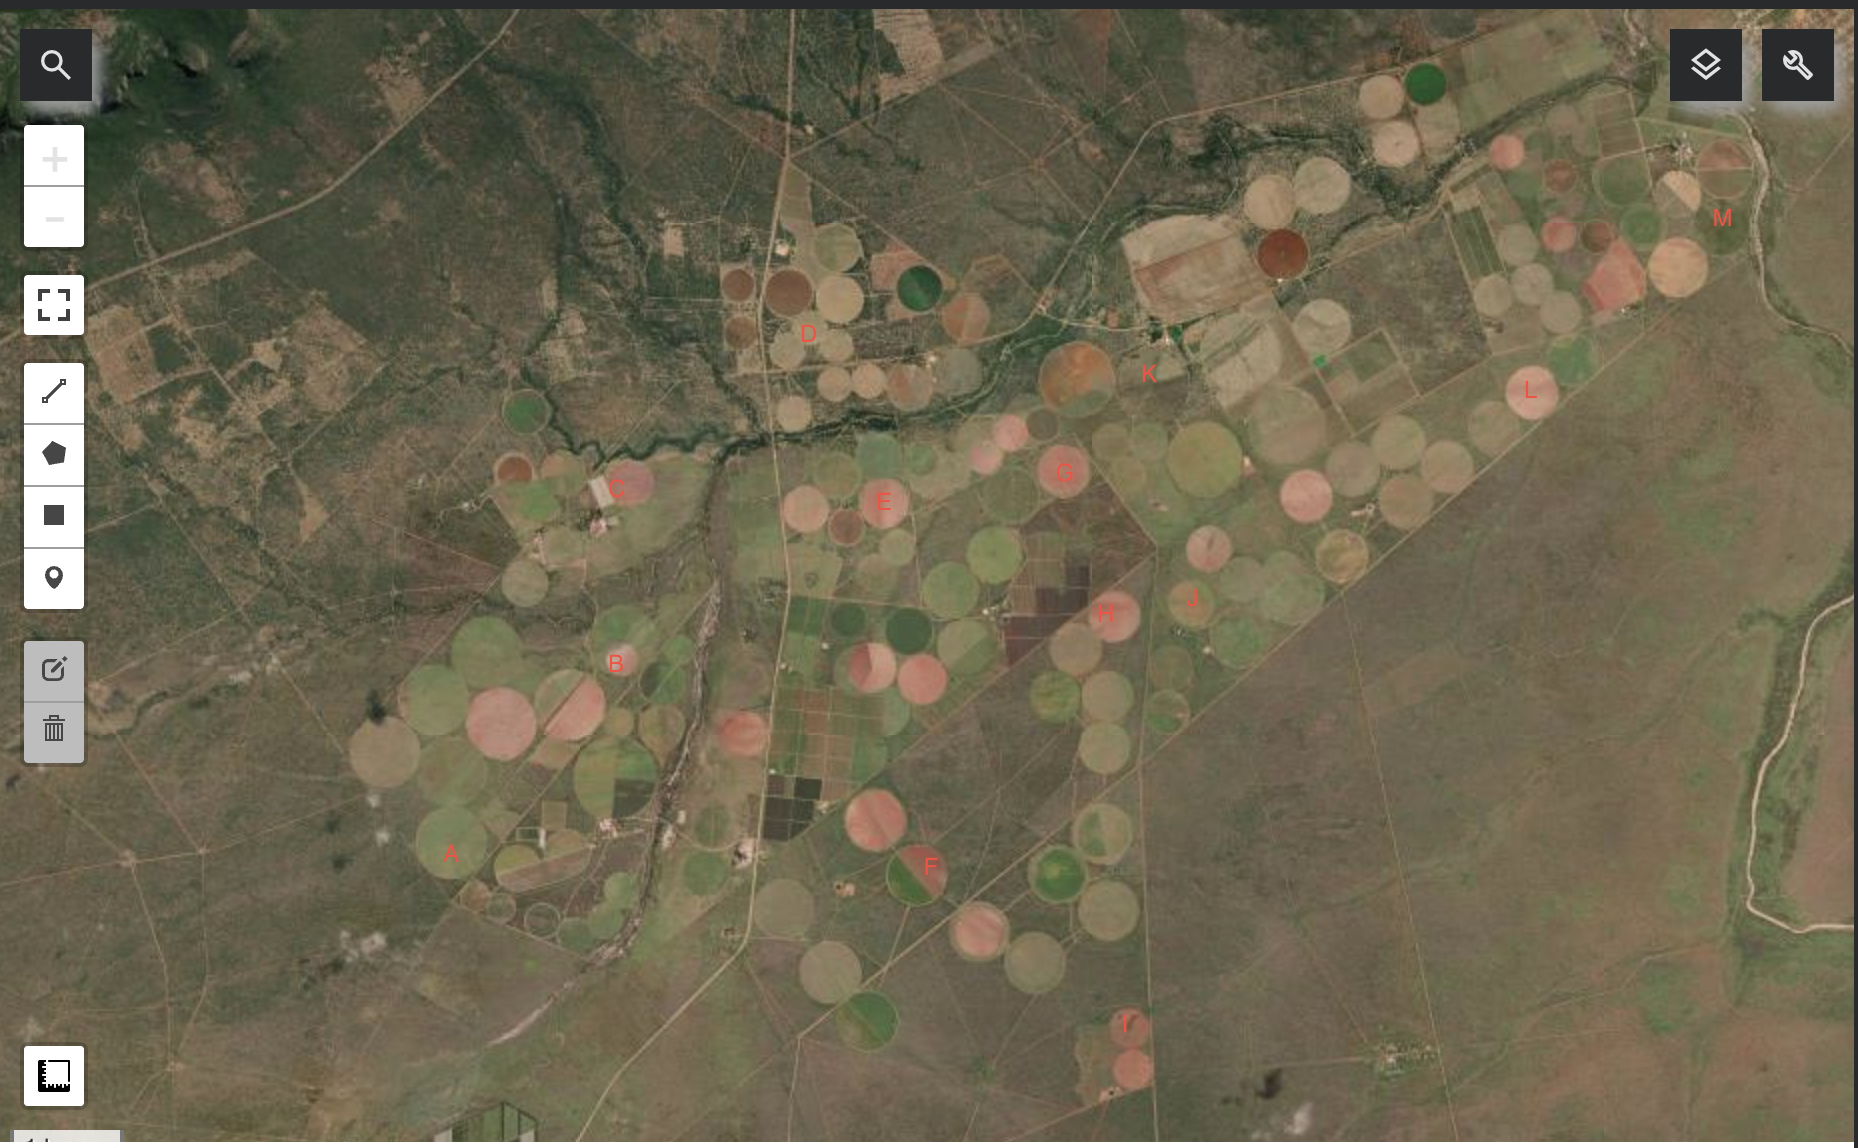

### Northern Field Labels: Detailed View

Here are the labeled images of the northern fields to help identify and locate specific areas.

#### North Fields I-M

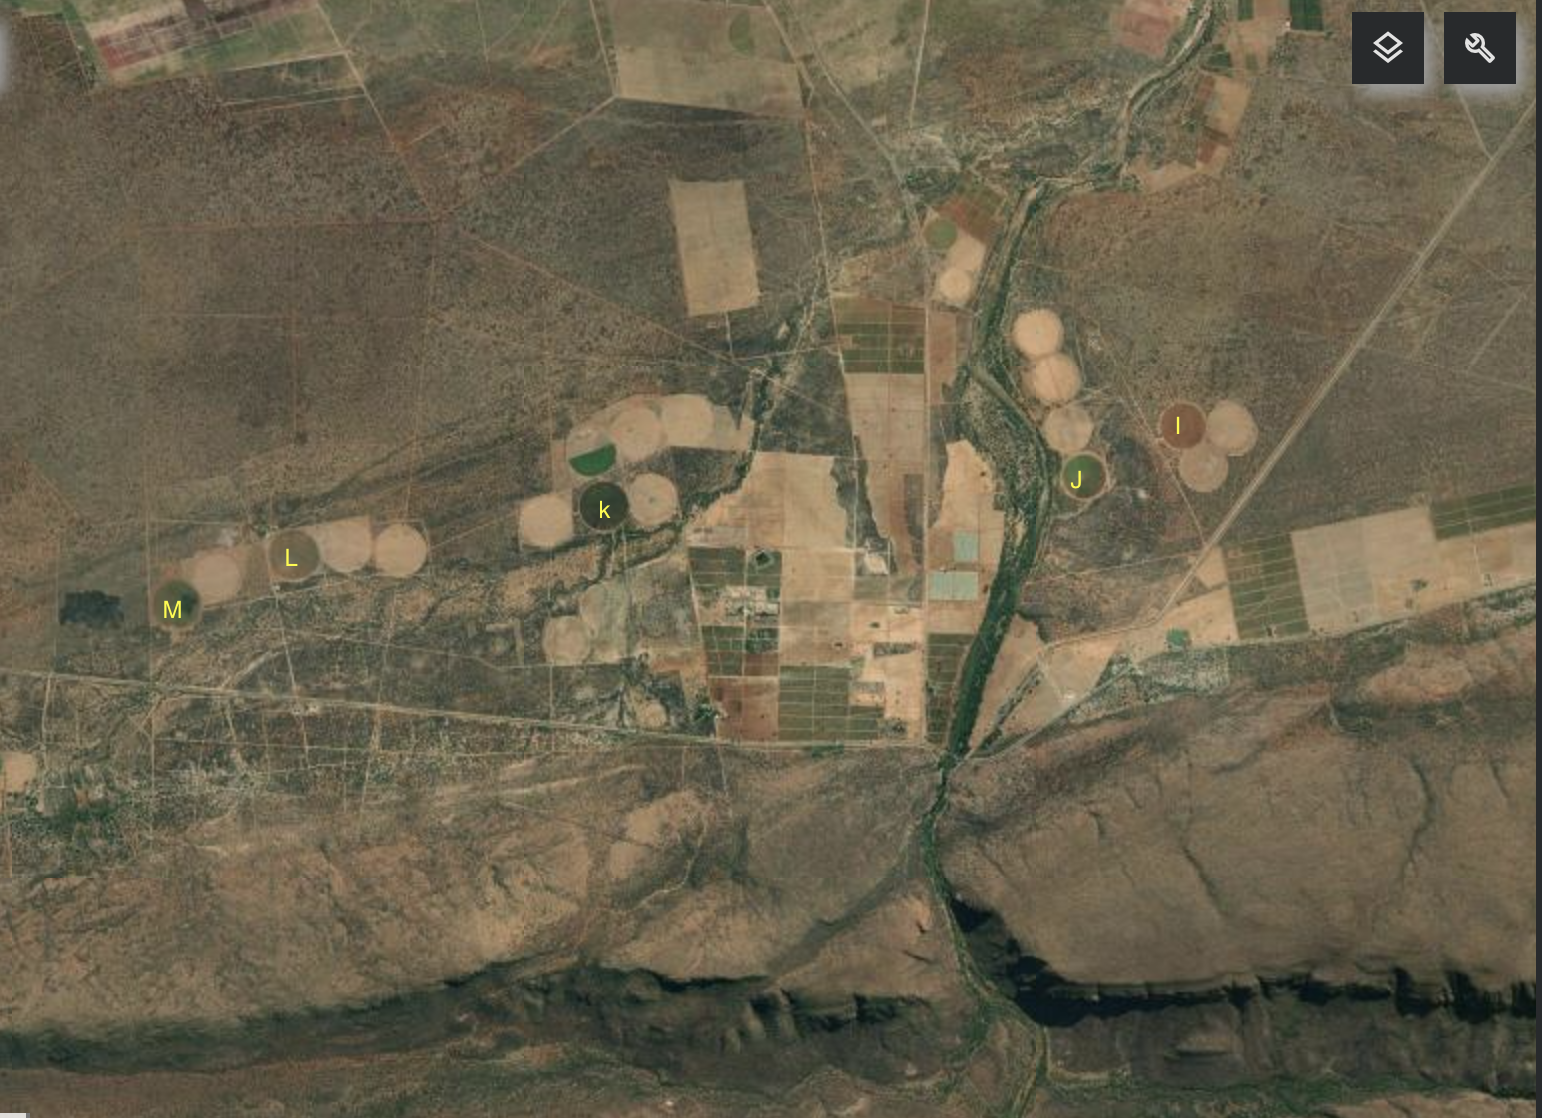

#### Northern Fields Labeled (Overview)

![Northen Fields Labeled](/content/Northen_fields_labeld.png)

### Clear the Data Bucket

Run the following cell if you wish to clear all collected field data from the `master_data_bucket` and start the collection process over.

In [ ]:
# WARNING!!! Run only to empty the bucket.
master_data_bucket = []
print("✅ master_data_bucket has been emptied.")

In [ ]:
# Use .user_roi for a single geometry or .user_rois for a collection
roi = Map.user_rois
if roi:
    print("ROI captured successfully!")
else:
    print("No ROI found. Did you draw it yet?")


In [ ]:
import ipywidgets as widgets
from IPython.display import display

def capture_and_tag_field():
    global master_data_bucket, Map, roi, get_ndvi_timeseries # Ensure global scope for modification

    # Check if Map exists and if a global roi variable has been set and is not None
    if 'Map' in globals() and 'roi' in globals() and roi is not None:
        print("✍️ ROI found. Please enter details for the field.")

        # Use input() for direct user interaction
        field_name = input("Enter a name for this field (e.g., 'South_Field_A', 'North_Field_1'): ")

        if not field_name:
            print("❌ Field name cannot be empty. Please draw the ROI again and provide a name.")
            Map.clear_draw_features()
            roi = None
            return

        print(f"Fetching NDVI for {field_name}...")
        ndvi_df = get_ndvi_timeseries(roi)

        if not ndvi_df.empty:
            ndvi_df['Field_ID'] = field_name
            # Determine location based on field name for 'Location' tag
            if 'South' in field_name:
                ndvi_df['Location'] = 'South'
            elif 'North' in field_name:
                ndvi_df['Location'] = 'North'
            else:
                ndvi_df['Location'] = 'Unknown'

            master_data_bucket.append(ndvi_df)
            print(f"✅ Data for '{field_name}' captured and tagged successfully. Appended to master_data_bucket.")
            print(f"Current master_data_bucket size: {len(master_data_bucket)}")

            # Clear drawn features to prepare for the next field
            Map.clear_draw_features()
            roi = None # Reset roi variable
            print("Map features cleared. Ready for next ROI.")

            # Display the head of the newly added dataframe
            display(ndvi_df.head())
        else:
            print(f"⚠️ No NDVI data found for the ROI of '{field_name}'. Please try again with a valid ROI.")
            Map.clear_draw_features()
            roi = None
    else:
        print("❌ No ROI found. Please ensure you have drawn a polygon on the map and run the 'roi = Map.user_rois' cell first.")

# Call the function to execute the capture and tag process
capture_and_tag_field()


Aggregate and Save

Once you have captured data for multiple fields, run this cell to merge them into one master file, sort by date, and save to a CSV.

In [ ]:
import pandas as pd

if len(master_data_bucket) > 0:
    # Combine everything
    final_df = pd.concat(master_data_bucket, ignore_index=False) # Keep original index (Date)

    # Reset the index to turn 'Date' into a column, then sort
    final_df = final_df.reset_index().sort_values('Date')

    # Save to CSV (Safe-keeping)
    final_df.to_csv('southern_potato_fields.csv', index=False)

    print("🎉 Data Aggregated!")
    print(f"Total Rows: {len(final_df)}")
    print(f"Fields: {final_df['Field_ID'].unique()}")
    display(final_df.head())
else:
    print("❌ The bucket is empty. Go back to drawing fields and capturing data.")

### Comparative Crop Health: Potato Fields (Seaborn Multi-Line Chart)

This chart, generated using the Seaborn library, provides a comparative view of the Normalized Difference Vegetation Index (NDVI) for different Sifra potato fields over time. Each line represents a unique field, allowing for quick visual assessment of crop health, growth stages, and potential stress factors across various locations.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

if 'final_df' in globals() and not final_df.empty:
    unique_fields = sorted(final_df['Field_ID'].unique().tolist())

    # Create a SelectMultiple widget for field selection
    field_selector = widgets.SelectMultiple(
        options=unique_fields,
        value=unique_fields,  # Default to all fields selected
        description='Select Fields:',
        disabled=False,
        layout={'height': '150px'}
    )

    def plot_selected_fields(selected_fields):
        if not selected_fields:
            print("Please select at least one field to plot.")
            return

        # Filter data for selected fields
        plot_df = final_df[final_df['Field_ID'].isin(list(selected_fields))]

        clear_output(wait=True)
        plt.figure(figsize=(14, 7))

        # Use Seaborn for easy multi-line plotting
        sns.lineplot(data=plot_df, x='Date', y='NDVI', hue='Field_ID', marker='o')

        plt.title("Comparative Crop Health: Sifra Potato Fields (2023-2025)", fontsize=16)
        plt.ylabel("NDVI (Greenness)")
        plt.xlabel("Date")
        plt.axhline(y=0.2, color='red', linestyle='--', label='Bare Soil')
        plt.grid(True, alpha=0.3)
        plt.legend(title='Field Name', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    print("Use the selector below to choose which fields to compare:")
    display(field_selector)
    # Link the widget to the plotting function and display its output
    output = widgets.interactive_output(plot_selected_fields, {'selected_fields': field_selector})
    display(output)

else:
    print("⚠️ No data to plot yet. Please ensure you have captured fields and run the 'Aggregate and Save' step (Step 4).")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap

# 1. Define a function to extract the time series
def get_ndvi_timeseries(roi_area):
    print("📊 Extracting historical satellite data... please wait.")

    # Load Sentinel-2 Collection
    collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(roi_area) \
        .filterDate('2023-01-01', '2025-12-31') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) # Mist belt adjustment

    def add_ndvi(image):
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        return image.addBands(ndvi).set('system:time_start', image.get('system:time_start'))

    # Map the NDVI function over the collection
    ndvi_col = collection.map(add_ndvi).select('NDVI')

    # Function to reduce each image in the collection to a single value for the ROI
    def reduce_image_to_value(image):
        # Reduce the image to get the mean NDVI within the ROI
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi_area,
            scale=10, # Sentinel-2 resolution is 10m
            bestEffort=True, # Handle cases where geometry might be too complex for exact calculation
            maxPixels=1e9 # Allow processing large number of pixels
        )
        # Get the 'NDVI' value from the stats dictionary
        ndvi_value = ee.List([stats.get('NDVI')])
        # Return a feature with the date and the NDVI value
        return ee.Feature(None, {
            'date': image.date().format('YYYY-MM-dd'),
            'NDVI': ndvi_value.get(0) # Extract the scalar value
        })

    # Map the reduction function over the NDVI image collection
    feature_collection = ndvi_col.map(reduce_image_to_value)

    # Convert the FeatureCollection to a list of dictionaries and then to a Pandas DataFrame
    if feature_collection.size().getInfo() == 0:
        print("No data found for the specified ROI and date range.")
        return pd.DataFrame(columns=['NDVI', 'Date']) # Return an empty DataFrame

    ts_data_list = feature_collection.reduceColumns(
        reducer=ee.Reducer.toList(2),
        selectors=['date', 'NDVI']
    ).getInfo()['list']

    ts_data = pd.DataFrame(ts_data_list, columns=['Date', 'NDVI'])

    ts_data['Date'] = pd.to_datetime(ts_data['Date'])
    ts_data = ts_data.set_index('Date').sort_index()

    # Filter out rows where NDVI might be null (e.g., if no data found for a region)
    ts_data = ts_data.dropna(subset=['NDVI'])
    # Also remove any rows where NDVI might be 0 (often indicates no valid data)
    ts_data = ts_data[ts_data['NDVI'] != ee.Number(0).getInfo()]

    return ts_data

# 2. Execute and Plot
if 'roi' in locals() and roi is not None:
    ndvi_df = get_ndvi_timeseries(roi)

    # Only plot if there is data
    if not ndvi_df.empty:
        plt.figure(figsize=(14, 6))
        plt.plot(ndvi_df.index, ndvi_df['NDVI'], color='#2ca02c', marker='o', markersize=4, linewidth=1, label='Sifra Field NDVI')

        # Add labels for your portfolio
        plt.title("NDVI 'Heartbeat': Crop Phenology (2023-2025)", fontsize=14)
        plt.ylabel("NDVI (Vegetation Health)")
        plt.xlabel("Date")
        plt.axhline(y=0.2, color='r', linestyle='--', label='Bare Soil Baseline')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print("No NDVI data available for plotting for the selected ROI and date range.")
else:
    print("⚠️ ROI not found. Please ensure you drew a polygon and ran the 'roi = Map.user_roi' cell.")


## Phase 2: Environmental Overlay - Analyzing Crop Health Drivers

Having successfully isolated and aggregated NDVI data for 13 specific potato fields on the south and north side of the mountain, Phase 2 of this project focuses on integrating environmental variables to gain deeper insights into crop health dynamics. This phase aims to move beyond simple observation of NDVI trends by correlating them with crucial factors such as humidity and temperature.

By overlaying this environmental data, we will systematically test specific hypotheses related to crop stress and yield, thereby enhancing our understanding of the factors influencing Sifra potato growth within the identified season windows. This analysis will be critical for informing targeted interventions and optimizing agricultural practices.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# 1. Load your 13-field data
# Assuming the file is named 'sifra_potato_analysis.csv' from the previous step
try:
    crop_df = pd.read_csv('sifra_potato_analysis.csv')
    crop_df['Date'] = pd.to_datetime(crop_df['Date'])
    print(f"✅ Loaded {len(crop_df)} rows of crop data.")
    print("Most recent crop data:")
    display(crop_df.tail())
except:
    print("⚠️ Could not find 'sifra_potato_analysis.csv'. Make sure you saved it!")

# 2. Fetch NASA Weather Data (South Farm Coordinates)
def fetch_weather(lat, lon, start, end):
    base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": "PRECTOTCORR,RH2M,T2M_MAX,T2M_MIN", # Rain, Humidity, Temp
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"
    }
    print("📡 Fetching NASA Weather Data...")
    response = requests.get(base_url, params=params)
    data = response.json()['properties']['parameter']

    # Create DataFrames for each parameter
    df_rain = pd.DataFrame.from_dict(data['PRECTOTCORR'], orient='index', columns=['Rainfall_mm'])
    df_humid = pd.DataFrame.from_dict(data['RH2M'], orient='index', columns=['Humidity_%'])
    df_temp = pd.DataFrame.from_dict(data['T2M_MAX'], orient='index', columns=['Max_Temp_C'])

    # Merge them
    weather = pd.concat([df_rain, df_humid, df_temp], axis=1)
    weather.index = pd.to_datetime(weather.index, format='%Y%m%d')
    return weather

# Set date range to match your crop data
start_date = "20230101"
end_date = "20250531"
south_weather = fetch_weather(-23.1148, 29.5100, start_date, end_date)
print("Most recent weather data:")
display(south_weather.tail())

# 3. Plotting the "Smoking Gun" (Dual-Axis Chart)
def plot_stress_overlay(crop_data, weather_data, season_year):
    # Filter for specific year to zoom in
    subset_weather = weather_data[weather_data.index.year == season_year]
    subset_crop = crop_data[crop_data['Date'].dt.year == season_year]

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot 1: The Crop Health (NDVI) - Left Axis
    sns.lineplot(data=subset_crop, x='Date', y='NDVI', ax=ax1, color='green', label='Sifra NDVI (Avg)', ci=None)
    ax1.set_ylabel('NDVI (Crop Health)', color='green', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='green')
    ax1.set_ylim(0, 0.9)

    # Plot 2: The Stressor (Rain/Humidity) - Right Axis
    ax2 = ax1.twinx()
    # We use a bar chart for Rain to see "Events"
    ax2.bar(subset_weather.index, subset_weather['Rainfall_mm'], color='blue', alpha=0.3, width=2, label='Rainfall (mm)')
    ax2.set_ylabel('Rainfall (mm)', color='blue', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(0, 100) # Scale rain so it doesn't dominate the graph

    plt.title(f"Forensic Analysis: Crop Health vs. Rainfall ({season_year})", fontsize=16)
    plt.show()

# Run the analysis for the "Failure" year (likely 2023 or early 2024)
plot_stress_overlay(crop_df, south_weather, 2024)

### Detailed 2025 Crop Cycle Analysis

This section focuses on retrieving and visualizing high-resolution NDVI data specifically for the 2025 growing season. This allows for a granular analysis of crop health during a more recent period, using a slightly relaxed cloud filter to ensure sufficient data points.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap
import seaborn as sns # Import seaborn for potential styling if needed

# 1. Update your collection filter for 2025 focus
def get_2025_data(roi_area):
    print("📅 Pulling 2025 High-Resolution data...")

    # Focus strictly on the 2025 growing window
    collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(roi_area) \
        .filterDate('2024-06-01', '2026-01-31') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)) # Relaxed for Mist Belt

    def add_ndvi(image):
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        return image.addBands(ndvi).set('system:time_start', image.get('system:time_start'))

    ndvi_col = collection.map(add_ndvi).select('NDVI')

    # Function to reduce each image in the collection to a single value for the ROI
    def reduce_image_to_value(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi_area,
            scale=10,
            bestEffort=True,
            maxPixels=1e9
        )
        ndvi_value = ee.List([stats.get('NDVI')])
        return ee.Feature(None, {
            'date': image.date().format('YYYY-MM-dd'),
            'NDVI': ndvi_value.get(0)
        })

    # Map the reduction function over the NDVI image collection
    feature_collection = ndvi_col.map(reduce_image_to_value)

    # Convert the FeatureCollection to a list of dictionaries and then to a Pandas DataFrame
    if feature_collection.size().getInfo() == 0:
        print("No data found for the specified ROI and date range.")
        return pd.DataFrame(columns=['NDVI', 'Date']) # Return an empty DataFrame

    ts_data_list = feature_collection.reduceColumns(
        reducer=ee.Reducer.toList(2),
        selectors=['date', 'NDVI']
    ).getInfo()['list']

    df = pd.DataFrame(ts_data_list, columns=['Date', 'NDVI'])

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index().reset_index() # Ensure Date is a column after sort

    # Filter out nulls and zeros
    df = df.dropna(subset=['NDVI'])
    df = df[df['NDVI'] != 0] # Use 0 directly for Python numeric comparison

    return df

# 2. Run it for your current ROI
if 'roi' in globals() and roi is not None:
    recent_ndvi = get_2025_data(roi)

    # 3. Plot the "Success" Year with Weather Overlay
    if not recent_ndvi.empty:
        # Ensure south_weather is available and convert its index to datetime if not already
        if 'south_weather' in globals() and not south_weather.empty:
            # Filter weather data to match the NDVI date range
            min_date = recent_ndvi['Date'].min()
            max_date = recent_ndvi['Date'].max()

            # Ensure south_weather index is datetime to allow filtering
            if not pd.api.types.is_datetime64_any_dtype(south_weather.index):
                south_weather.index = pd.to_datetime(south_weather.index)

            subset_weather = south_weather.loc[min_date.strftime('%Y-%m-%d'):max_date.strftime('%Y-%m-%d')]

            fig, ax1 = plt.subplots(figsize=(14, 6))

            # Plot 1: NDVI (Left Axis)
            sns.lineplot(data=recent_ndvi, x='Date', y='NDVI', ax=ax1, color='darkgreen', marker='s', label='2025 Sifra Success')
            ax1.set_ylabel('NDVI (Vegetation Health)', color='darkgreen', fontsize=12)
            ax1.tick_params(axis='y', labelcolor='darkgreen')
            ax1.set_ylim(0, recent_ndvi['NDVI'].max() * 1.1) # Dynamic y-limit
            ax1.set_xlabel('Date')

            # Plot 2: Rainfall (Right Axis)
            ax2 = ax1.twinx()
            ax2.bar(subset_weather.index, subset_weather['Rainfall_mm'], color='skyblue', alpha=0.6, width=1, label='Rainfall (mm)')
            ax2.set_ylabel('Rainfall (mm)', color='skyblue', fontsize=12)
            ax2.tick_params(axis='y', labelcolor='skyblue')
            ax2.set_ylim(0, subset_weather['Rainfall_mm'].max() * 1.5) # Dynamic y-limit for rain

            # Add a bare soil baseline for NDVI
            ax1.axhline(y=0.2, color='r', linestyle='--', label='Bare Soil Baseline')

            plt.title("Detailed 2025 Crop Cycle Analysis with Rainfall Overlay", fontsize=14)
            fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
            ax1.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("⚠️ No 'south_weather' data found. Plotting NDVI only.")
            plt.figure(figsize=(14, 6))
            plt.plot(recent_ndvi['Date'], recent_ndvi['NDVI'], color='darkgreen', marker='s', label='2025 Sifra Success')
            plt.title("Detailed 2025 Crop Cycle Analysis", fontsize=14)
            plt.ylabel("NDVI")
            plt.xlabel("Date")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()
    else:
        print("⚠️ No recent NDVI data available for plotting for the selected ROI and date range.")
else:
    print("❌ ROI not found. Please ensure you drew a polygon and ran the 'roi = Map.user_rois' cell.")

## Combine and Label


By combining the two datasets southern_fields.csv and northen_fields.csv, I created a master dataset with properly labelled locations.


In [ ]:
import pandas as pd

# 1. Load the two separate CSV files
# Ensure the filenames match your local files exactly
north_df = pd.read_csv('northen_potato_fields.csv')
south_df = pd.read_csv('southern_potato_fields.csv')

# 2. Add the 'Location' Label
# This is critical for hue-based plotting and statistical grouping later
north_df['Location'] = 'North'
south_df['Location'] = 'South'

# 3. Combine into the Master Dataframe
master_df = pd.concat([north_df, south_df], ignore_index=True)

# 4. Clean up the dates
# Ensuring pandas treats 'Date' as a datetime object for correct plotting
master_df['Date'] = pd.to_datetime(master_df['Date'])

# 5. Sort by Date so the time-series line doesn't jump around
master_df = master_df.sort_values(by=['Location', 'Date'])

# 6. Save the final Master Dataset
master_df.to_csv('master_potato_analysis.csv', index=False)

print("🎉 Master Dataset Created!")
print(f"📍 Total Fields: {master_df['Field_ID'].nunique()}")
print(f"📊 Total Data Points: {len(master_df)}")
print("\n--- Quick Look at the Combined Data ---")
print(master_df.groupby('Location')['NDVI'].describe())

The next step create a time-series plot comparing the Normalized Difference Vegetation Index (NDVI) for the North and South regions from 2023 -2025. A mis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import register_matplotlib_converters

# 1. Register converters to prevent the Timestamp conversion error
register_matplotlib_converters()

# 2. Use the master_df we created in the previous step
# (Make sure 'master_df' is in your memory)
if 'master_df' in locals():
    plt.figure(figsize=(14, 8))

    # Set the style for a professional portfolio look
    sns.set_theme(style="whitegrid")

    # 3. Plotting by Location
    # We use 'Date' for x and 'NDVI' for y
    plot = sns.lineplot(
        data=master_df,
        x='Date',
        y='NDVI',
        hue='Location',
        style='Location', # Adds different line styles for better visibility
        markers=True,
        dashes=False,
        palette=['#1f77b4', '#ff7f0e'] # North=Blue, South=Orange
    )

    # 4. The Fix for axvline: Pass the date as a string or use matplotlib.dates
    # This avoids the Timestamp object conflict
    plt.axvline(x=pd.to_datetime('2024-06-01'), color='red', linestyle='--', alpha=0.6, label='Mist Belt Window')

    # Formatting
    plt.title("The Sifra Paradox: North vs. South Performance Comparison (2023-2025)", fontsize=16)
    plt.ylabel("NDVI (Crop Health Index)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.ylim(0, 0.85)
    plt.legend(title='Farm Location', loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 'master_df' not found. Please run the merger code from the previous step first!")

The visualizationa above shows the islated fields between 2023-2025. However, the main focus period was 2024, one can see a clear peak around 2024-05 indicating that the farmer planted potato cops on the isolated fields at that time.

The year before (2023) and after (2025) shows peask below the NDVI 0.7 mark, indicating that those fields were rested for the season or other crops rotation crops where planted.

The next step is to only look atd data from 2024 and also identify new potato fields for 2025. This will make the data more accurate and this will make the analysis more insightful.

In [ ]:
import pandas as pd

# 1. Load your current master dataset
# (Assuming you saved it as 'master_potato_analysis.csv')
master_df = pd.read_csv('master_potato_analysis.csv')
master_df['Date'] = pd.to_datetime(master_df['Date'])

# 2. Filter for 2024 only
# This drops all rows from 2023, 2025, and 2026
df_2024 = master_df[(master_df['Date'] >= '2024-01-01') &
                    (master_df['Date'] <= '2024-12-31')].copy()

# 3. Label it as 2024 Observations
# Adding a 'Season' column makes it easy to compare against 2025 later
df_2024['Season'] = '2024'

# 4. Save this as a specific "Failure Year" dataset
df_2024.to_csv('sifra_2024_observations.csv', index=False)

print("✅ 2024 Data Isolated!")
print(f"Remaining Rows: {len(df_2024)}")
print(f"Date Range: {df_2024['Date'].min().date()} to {df_2024['Date'].max().date()}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the isolated 2024 data you just created
df_2024 = pd.read_csv('sifra_2024_observations.csv')
df_2024['Date'] = pd.to_datetime(df_2024['Date'])

# 2. Calculate Key Metrics per Field
# We want to see the 'Peak' each field reached and its 'Average' health
field_stats = df_2024.groupby(['Field_ID', 'Location']).agg(
    Peak_NDVI=('NDVI', 'max'),
    Average_NDVI=('NDVI', 'mean')
).reset_index()

# 3. Create the Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Plot A: Peak Potential (The "Best Case" for each field)
sns.boxplot(data=field_stats, x='Location', y='Peak_NDVI',
            palette=['#1f77b4', '#ff7f0e'], ax=axes[0], width=0.5)
sns.stripplot(data=field_stats, x='Location', y='Peak_NDVI',
              color=".3", alpha=0.6, ax=axes[0]) # Adds individual field dots
axes[0].set_title('A. Peak Performance (Max NDVI)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Max NDVI Reached')

# Plot B: Season Average (The "Economic Reality" of each field)
sns.boxplot(data=field_stats, x='Location', y='Average_NDVI',
            palette=['#1f77b4', '#ff7f0e'], ax=axes[1], width=0.5)
sns.stripplot(data=field_stats, x='Location', y='Average_NDVI',
              color=".3", alpha=0.6, ax=axes[1])
axes[1].set_title('B. Overall Season Health (Mean NDVI)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average NDVI')

plt.suptitle('2024 Sifra Performance Analysis: North vs. South Statistical Gap', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print the summary numbers for your report
print("📊 --- Statistical Summary (2024) ---")
print(field_stats.groupby('Location')[['Peak_NDVI', 'Average_NDVI']].describe().T)


In [ ]:
import pandas as pd

# 1. Load the 2024 Master (The Forensic Baseline)
df_2024 = pd.read_csv('sifra_2024_observations.csv')

# 2. Load the Two New 2025 Datasets (from your screenshots)
# These represent the new pivots the farmer rotated to
df_north_new = pd.read_csv('northen_potato_fields.csv')
df_south_new = pd.read_csv('southern_potato_fields.csv')

# 3. Label and Clean the New Data
# We add Season='2025' and ensure Location is correct
df_north_new['Season'] = '2025'
df_north_new['Location'] = 'North'

df_south_new['Season'] = '2025'
df_south_new['Location'] = 'South'

# 4. Combine into the Final Multi-Season Master
final_master = pd.concat([df_2024, df_north_new, df_south_new], ignore_index=True)

# 5. Final Cleaning
final_master['Date'] = pd.to_datetime(final_master['Date'])
# Ensure we only keep 2025 data for the new rows (dropping any pre-2025 noise if it exists)
mask_2025 = (final_master['Season'] == '2025') & (final_master['Date'].dt.year < 2025)
final_master = final_master[~mask_2025]

# 6. Save the definitive project file
final_master.to_csv('final_master_potato_dataset.csv', index=False)

print("🚀 Final Master Dataset Created: 'final_master_potato_dataset.csv'")
print(f"📊 Total Observations: {len(final_master)}")
print(f"📍 Locations: {final_master['Location'].unique()}")
print(f"📅 Seasons: {final_master['Season'].unique()}")

# Display a quick summary of the comparison we are about to make
print("\n--- Season-by-Season Performance Summary ---")
print(final_master.groupby(['Season', 'Location'])['NDVI'].agg(['mean', 'max', 'std']))


# Recources:


- **[1]** HZPC Holland B.V. (2024). *Sifra Potato Variety Profile*. [Online]. Available: [https://www.hzpc.com/our-potato-varieties/sifra](https://www.hzpc.com/our-potato-varieties/sifra)
- **[2]** Al-Gaadi, K., et al. (2016). *Prediction of Potato Crop Yield Using Precision Agriculture Techniques*. PLOS ONE. [https://doi.org/10.1371/journal.pone.0162219](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0162219)